
# Домашнє завдання: Інтеграція Python та SQL: запити даних

Це ДЗ передбачене під виконання на локальній машині. Виконання з Google Colab буде суттєво ускладнене.

## Підготовка
1. Переконайтесь, що у вас встановлены необхідні бібліотеки:
   ```bash
   pip install sqlalchemy pymysql pandas matplotlib seaborn python-dotenv
   ```

2. Створіть файл `.env` з параметрами підключення до бази даних classicmodels. Базу даних ви можете отримати через

  - docker-контейнер згідно існтрукції в [документі](https://www.notion.so/hannapylieva/Docker-1eb94835849480c9b2e7f5dc22ee4df9), також відео інструкції присутні на платформі - уроки "MySQL бази, клієнт для роботи з БД, Docker і ChatGPT для запитів" та "Як встановити Docker для роботи з базами даних без терміналу"
  - або встановивши локально цю БД - для цього перегляньте урок "Опціонально. Встановлення MySQL та  БД Сlassicmodels локально".
  
  Приклад `.env` файлу ми створювали в лекції. Ось його обовʼязкове наповнення:
    ```
    DB_HOST=your_host
    DB_PORT=3306 або 3307 - той, який Ви налаштували
    DB_USER=your_username
    DB_PASSWORD=your_password
    DB_NAME=classicmodels
    ```
  Якщо ви створили цей файл під час перегляду лекції - **новий створювати не треба**. Замініть лише назву БД, або пропишіть назву в коді створення підключення (замість отримання назви цільової БД зі змінних оточення). Але переконайтесь, що до `.env` файл лежить в тій самій папці, що і цей ноутбук.

  **УВАГА!** НЕ копіюйте скрит для **створення** `.env` файлу. В лекції він наводиться для прикладу. І давалось пояснення, що в реальних проєктах ми НІКОЛИ не пишемо доступи до бази в коді. Копіювання скрипта для створення `.env` файлу сюди в ДЗ буде вважатись грубою помилкою і ми зніматимемо бали.

3. Налаштуйте підключення через SQLAlchemy до БД за прикладом в лекції.

Рекомендую вивести (відобразити) змінну engine після створення. Вона має бути не None! Якщо None - значить у Вас не підтягнулись налаштування з .env файла.

Ви також можете налаштувати параметри підключення до БД без .env файла, просто прописавши текстом в відповідних місцях. Це - не рекомендований підхід.


In [1]:
!pip install sqlalchemy pymysql pandas matplotlib seaborn python-dotenv

In [2]:
# перевірка, що .env файл існує
import os
print(os.path.exists(".env"))

True


In [3]:
from dotenv import load_dotenv
import os

load_dotenv()

host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT")
user = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
database = os.getenv("DB_NAME")

In [4]:
from sqlalchemy import create_engine

connection_string = f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}"

engine = create_engine(connection_string)

print("Підключення створено")

Підключення створено


### Завдання 1: Простий запит (1 бал)

Ми працюємо з БД Classicmodels.

**Виведіть інформацію про продукти на складі** з наступними полями:
- назва продукту (productName)
- лінійка продукту (productLine)
- кількість на складі (quantityInStock)
- ціна закупки (buyPrice)

Зчитайте дані з БД з допомогою `pd.read_sql()` з SQLAlchemy engine, який ви створили на етапі підготовки.

Виведіть перші 10 продуктів, відсортованих за кількістю на складі (від більшої кількості до меншої).

In [5]:
import pandas as pd

query = """
SELECT productName,
       productLine,
       quantityInStock,
       buyPrice
FROM products
ORDER BY quantityInStock DESC
LIMIT 10
"""

df = pd.read_sql(query, engine)
df

,productName,productLine,quantityInStock,buyPrice
0,2002 Suzuki XREO,Motorcycles,9997,66.27
1,1995 Honda Civic,Classic Cars,9772,93.89
2,America West Airlines B757-200,Planes,9653,68.80
3,2002 Chevy Corvette,Classic Cars,9446,62.11
4,1932 Model A Ford J-Coupe,Vintage Cars,9354,58.48
5,1982 Ducati 996 R,Motorcycles,9241,24.14
6,1912 Ford Model T Delivery Wagon,Vintage Cars,9173,46.91
7,1976 Ford Gran Torino,Classic Cars,9127,73.49
8,1968 Dodge Charger,Classic Cars,9123,75.16
9,1965 Aston Martin DB5,Classic Cars,9042,65.96



### Завдання 2: Аналітика замовлень за 2004 рік (3 бали)

**Виведіть детальну інформацію про замовлення за 2004 рік** з наступними полями:
- Номер замовлення (orderNumber)
- Дата замовлення (orderDate)
- Статус замовлення (status)
- Ім'я клієнта (customerName)
- Країна клієнта (country)
- Загальна сума замовлення (сума всіх orderdetails.quantityOrdered * orderdetails.priceEach)

Використайте JOIN для об'єднання таблиць orders, customers, orderdetails. Додайте параметризацію за роком (тільки замовлення за 2004 рік).

Використайте `text()` та named parameters для формування запиту з SQLAlchemy.

Після отримання даних з БД проведіть обчислення з Python та напишіть висновки:
1. Побудуйте стовпчасту діаграму суми замовлень по країнам і напишіть, в якій країні найбільша сума замовлень за 2004 рік.
2. В країні з найбільшою кількістю замовлень знайдіть клієнта, який зробив замовлень на найбільшу суму і виведіть імʼя цього клієнта, на яку суму він зробив замовлень і який % від всіх замовлень в цій країні становить його сума замовлень за рік.

In [6]:
from sqlalchemy import text

query = text("""
SELECT 
    o.orderNumber,
    o.orderDate,
    o.status,
    c.customerName,
    c.country,
    SUM(od.quantityOrdered * od.priceEach) AS totalAmount
FROM orders o
JOIN customers c
    ON o.customerNumber = c.customerNumber
JOIN orderdetails od
    ON o.orderNumber = od.orderNumber
WHERE YEAR(o.orderDate) = :year
GROUP BY 
    o.orderNumber,
    o.orderDate,
    o.status,
    c.customerName,
    c.country
ORDER BY totalAmount DESC
""")

df_orders_2004 = pd.read_sql(query, engine, params={"year": 2004})
df_orders_2004.head()

,orderNumber,orderDate,status,customerName,country,totalAmount
0,10287,2004-08-30,Shipped,"Vida Sport, Ltd",Switzerland,61402.00
1,10310,2004-10-16,Shipped,"Toms Spezialitäten, Ltd",Germany,61234.67
2,10212,2004-01-16,Shipped,Euro+ Shopping Channel,Spain,59830.55
3,10222,2004-02-19,Shipped,Collectable Mini Designs Co.,USA,56822.65
4,10312,2004-10-21,Shipped,Mini Gifts Distributors Ltd.,USA,55639.66


In [7]:
country_sales = (
    df_orders_2004.groupby("country", as_index=False)["totalAmount"]
    .sum()
    .sort_values("totalAmount", ascending=False)
)

country_sales.head()

,country,totalAmount
20,USA,1526499.65
6,France,506660.01
16,Spain,439881.84
19,UK,238193.93
11,New Zealand,233362.27


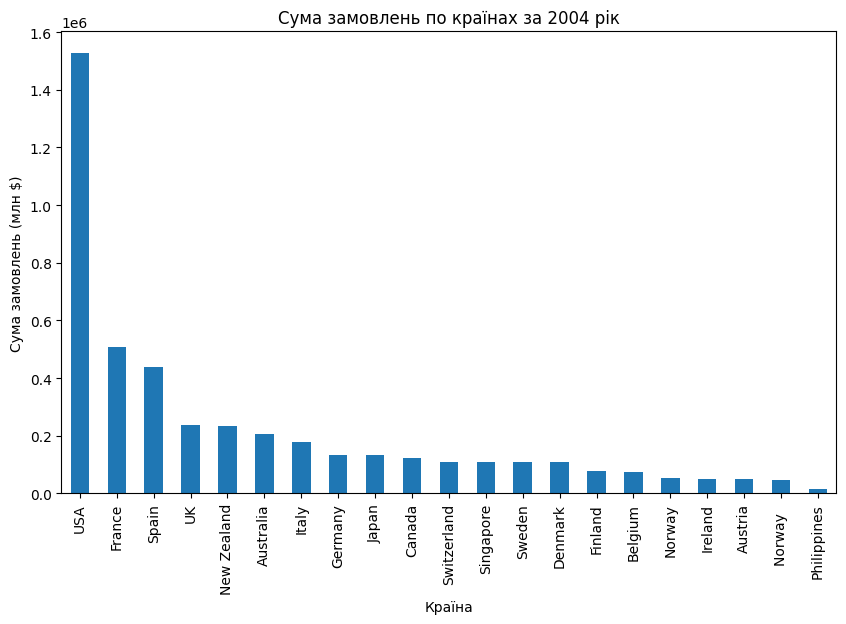

In [8]:
import matplotlib.pyplot as plt

country_sales.plot(
    x="country",
    y="totalAmount",
    kind="bar",
    figsize=(10,6),
    legend=False,
    title="Сума замовлень по країнах за 2004 рік"
),

plt.ylabel("Сума замовлень (млн $)"),
plt.xlabel("Країна");

In [9]:
country_order_counts = (
    df_orders_2004.groupby("country", as_index=False)["orderNumber"]
    .count()
    .rename(columns={"orderNumber": "orderCount"})
    .sort_values("orderCount", ascending=False)
)

country_order_counts.head()

,country,orderCount
20,USA,53
6,France,19
16,Spain,14
19,UK,7
0,Australia,6


In [10]:
top_country_df = df_orders_2004[df_orders_2004["country"] == country_order_counts.iloc[0]["country"]]

customer_sales_in_top_country = (
    top_country_df.groupby("customerName", as_index=False)["totalAmount"]
    .sum()
    .sort_values("totalAmount", ascending=False)
)

customer_sales_in_top_country.head()

,customerName,totalAmount
17,Mini Gifts Distributors Ltd.,231562.53
12,Land of Toys Inc.,126792.53
6,Diecast Classics Inc.,98509.25
13,Marta's Replicas Co.,90545.37
4,Collectable Mini Designs Co.,80375.24


In [11]:
total_country_sales = top_country_df["totalAmount"].sum()
top_customer_share = customer_sales_in_top_country.iloc[0]["totalAmount"] / total_country_sales * 100

print("Клієнт:", customer_sales_in_top_country.iloc[0]["customerName"])
print("Сума замовлень клієнта:", round(customer_sales_in_top_country.iloc[0]["totalAmount"], 2))
print("Частка від усіх замовлень країни:", round(top_customer_share, 2), "%")

Клієнт: Mini Gifts Distributors Ltd.
Сума замовлень клієнта: 231562.53
Частка від усіх замовлень країни: 15.17 %


1. У США найбільша сума замовлень за 2004 рік - приблизно 1,53 млн $.

2. Найбільша кількість замовлень була зроблена також в США, що свідчить про високу активність клієнтів на цьому ринку.

У країні з найбільшою кількістю замовлень найбільшу суму замовлень зробив клієнт Mini Gifts Distributors Ltd. на суму 231562.53 $. Його внесок становить 15.17 % від загальної суми замовлень у США за 2004 рік, що робить цього клієнта одним із ключових для компанії на цьому ринку.


### Завдання 3: Аналітичний запит - Топ продуктів по продажах (6 балів)

В цьому завданні ви отримуєте 1 бал за правильний SQL запит і по 1 балу за кожне завдання з Python.

**Проведіть аналіз прибутковості продуктів** та для цього дістаньте з БД інформацію з наступними полями:
- Назва продукту
- Лінійка продукту (productLine)
- Загальний дохід з цього продукту (сума quantity * priceEach)
- Ранг продукту по доходу (тобто яке місце посідає цей продукт за доходом серед усіх продуктів в нашому магазині)
- Який відсоток від загального доходу компанії складає цей продукт
- Різниця з середнім доходом по лінійці продукту (в %)

Відсортуйте дані за спаданням значень колонки "Який відсоток від загального доходу компанії складає цей продукт".

При створенні SQL запиту вам можуть стати в нагоді:
- **CTE** для розрахунку доходу по кожному продукту
- **Віконні функції** для ранжування та порівняння з середнім

Після отримання даних з БД проведіть обчислення (де треба) з Python та напишіть висновки:
1. Який відсоток від загального доходу складає ТОП1 продукт і що це за продукт?
2. Створіть стовпчикову діаграму топ-10 продуктів по доходу. В скільки разів відрізняється сумарний дохід за ТОП1 продуктом від 10го продукту за сумою доходу?
3. Створіть кругову діаграму розподілу доходу по лініях продуктів. Який відсоток від всіх продажів становлять продажі за ТОП2 лініями сумарно?
4. Розрахуйте та виведіть за принципом Парето (80/20) - скільки продуктів дають 80% доходу. Тобто нам треба знайти кількість продуктів сумарне значення "відсотку від загального доходу компанії", яких складає 80 починаючи з продукту з найбільшим цим відсотком.
5. Зробіть ще будь-яке аналітичне дослідження, яке дасть нам більше розуміння наших даних, що ми дістали в БД в цьому завданні. Сформоване питання до даних і обчислення має бути обовʼязково. Візуалізація - опціонально.

Візуалізацію можна створювати з будь-якою бібліотекою на ваш вибір.

In [12]:
query = text("""
WITH product_revenue AS (
    SELECT
        p.productName,
        p.productLine,
        SUM(od.quantityOrdered * od.priceEach) AS totalRevenue
    FROM products p
    JOIN orderdetails od
        ON p.productCode = od.productCode
    GROUP BY
        p.productName,
        p.productLine
)
SELECT
    productName,
    productLine,
    totalRevenue,
    RANK() OVER (ORDER BY totalRevenue DESC) AS revenueRank,
    ROUND(totalRevenue * 100.0 / SUM(totalRevenue) OVER (), 2) AS revenueSharePercent,
    ROUND(
        (totalRevenue - AVG(totalRevenue) OVER (PARTITION BY productLine))
        * 100.0
        / AVG(totalRevenue) OVER (PARTITION BY productLine),
        2
    ) AS diffFromLineAvgPercent
FROM product_revenue
ORDER BY revenueSharePercent DESC
""")

df_products = pd.read_sql(query, engine)
df_products.head()

,productName,productLine,totalRevenue,revenueRank,revenueSharePercent,diffFromLineAvgPercent
0,1992 Ferrari 360 Spider red,Classic Cars,276839.98,1,2.88,165.78
1,2001 Ferrari Enzo,Classic Cars,190755.86,2,1.99,83.14
2,1952 Alpine Renault 1300,Classic Cars,190017.96,3,1.98,82.43
3,2003 Harley-Davidson Eagle Drag Bike,Motorcycles,170686.00,4,1.78,97.87
4,1968 Ford Mustang,Classic Cars,161531.48,5,1.68,55.08


In [13]:
df_products.info()
df_products.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   productName             109 non-null    object 
 1   productLine             109 non-null    object 
 2   totalRevenue            109 non-null    float64
 3   revenueRank             109 non-null    int64  
 4   revenueSharePercent     109 non-null    float64
 5   diffFromLineAvgPercent  109 non-null    float64
dtypes: float64(3), int64(1), object(2)
memory usage: 5.2+ KB


,productName,productLine,totalRevenue,revenueRank,revenueSharePercent,diffFromLineAvgPercent
0,1992 Ferrari 360 Spider red,Classic Cars,276839.98,1,2.88,165.78
1,2001 Ferrari Enzo,Classic Cars,190755.86,2,1.99,83.14
2,1952 Alpine Renault 1300,Classic Cars,190017.96,3,1.98,82.43
3,2003 Harley-Davidson Eagle Drag Bike,Motorcycles,170686.00,4,1.78,97.87
4,1968 Ford Mustang,Classic Cars,161531.48,5,1.68,55.08
5,1969 Ford Falcon,Classic Cars,152543.02,6,1.59,46.45
6,1980s Black Hawk Helicopter,Planes,144959.91,7,1.51,82.22
7,1998 Chrysler Plymouth Prowler,Classic Cars,142530.63,8,1.48,36.84
8,1917 Grand Touring Sedan,Vintage Cars,140535.60,9,1.46,87.64
9,2002 Suzuki XREO,Motorcycles,135767.03,10,1.41,57.39


In [14]:
top1_product = df_products.iloc[0]

print("ТОП1 продукт:", top1_product["productName"])
print("Лінійка:", top1_product["productLine"])
print("Дохід:", round(top1_product["totalRevenue"], 2))
print("Частка від загального доходу:", top1_product["revenueSharePercent"], "%")

ТОП1 продукт: 1992 Ferrari 360 Spider red
Лінійка: Classic Cars
Дохід: 276839.98
Частка від загального доходу: 2.88 %


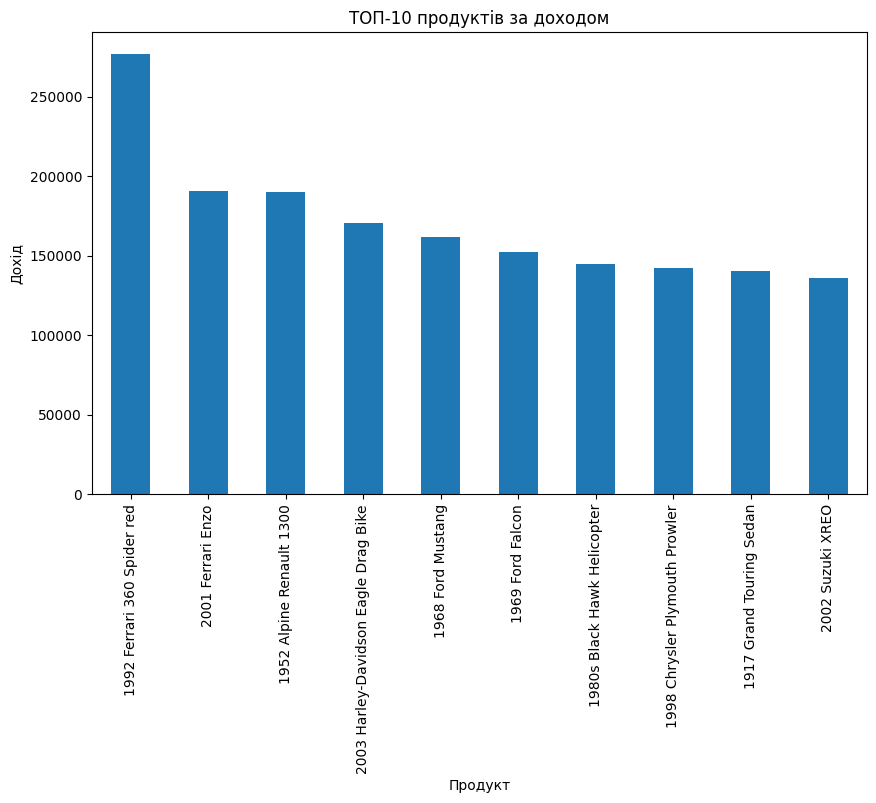

In [15]:
top10_products = df_products.head(10)

ax = top10_products.plot(
    x="productName",
    y="totalRevenue",
    kind="bar",
    figsize=(10, 6),
    legend=False,
    title="ТОП-10 продуктів за доходом"
)

ax.set_xlabel("Продукт")
ax.set_ylabel("Дохід");

In [16]:
ratio_top1_to_10 = top10_products.iloc[0]["totalRevenue"] / top10_products.iloc[9]["totalRevenue"]

print("Дохід ТОП1 більший за дохід 10-го продукту у", round(ratio_top1_to_10, 2), "рази")

Дохід ТОП1 більший за дохід 10-го продукту у 2.04 рази


In [17]:
line_revenue = (
    df_products.groupby("productLine", as_index=False)["totalRevenue"]
    .sum()
    .sort_values("totalRevenue", ascending=False)
)

line_revenue

,productLine,totalRevenue
0,Classic Cars,3853922.49
6,Vintage Cars,1797559.63
1,Motorcycles,1121426.12
5,Trucks and Buses,1024113.57
2,Planes,954637.54
3,Ships,663998.34
4,Trains,188532.92


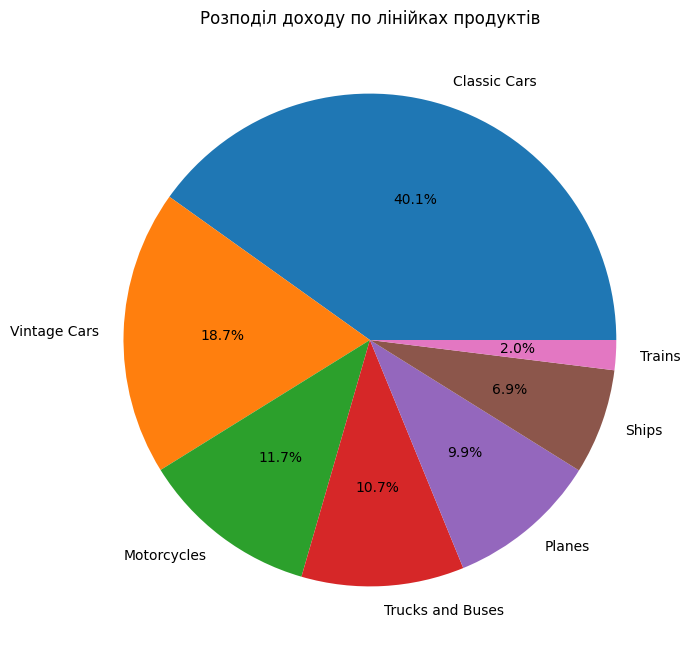

In [18]:
line_revenue.set_index("productLine")["totalRevenue"].plot(
    kind="pie",
    figsize=(8, 8),
    autopct="%1.1f%%",
    ylabel="",
    title="Розподіл доходу по лінійках продуктів"
);

In [19]:
top2_lines_share = (
    line_revenue.head(2)["totalRevenue"].sum() / line_revenue["totalRevenue"].sum() * 100
)

print("ТОП2 лінійки складають", round(top2_lines_share, 2), "% від усіх продажів")

ТОП2 лінійки складають 58.84 % від усіх продажів


In [20]:
df_pareto = df_products.copy()

df_pareto["cumulativeShare"] = df_pareto["revenueSharePercent"].cumsum()

pareto_count = (df_pareto["cumulativeShare"] <= 80).sum()

if df_pareto.iloc[pareto_count - 1]["cumulativeShare"] < 80:
    pareto_count += 1

print("Кількість продуктів, які формують 80% доходу:", pareto_count)

Кількість продуктів, які формують 80% доходу: 72


In [21]:
line_variability = (
    df_products.groupby("productLine")
    .agg(
        avgRevenue=("totalRevenue", "mean"),
        maxRevenue=("totalRevenue", "max"),
        minRevenue=("totalRevenue", "min"),
        stdRevenue=("totalRevenue", "std")
    )
    .reset_index()
    .sort_values("stdRevenue", ascending=False)
)

line_variability

,productLine,avgRevenue,maxRevenue,minRevenue,stdRevenue
0,Classic Cars,104160.067297,276839.98,30972.87,50118.743060
1,Motorcycles,86263.547692,170686.00,33268.76,37657.065076
6,Vintage Cars,74898.317917,140535.60,28052.94,31695.446231
5,Trucks and Buses,93101.233636,119085.25,46519.05,28205.845167
2,Planes,79553.128333,144959.91,42692.53,26281.782394
3,Ships,73777.593333,112427.12,47550.40,18379.460035
4,Trains,62844.306667,82617.12,52123.81,17144.060676


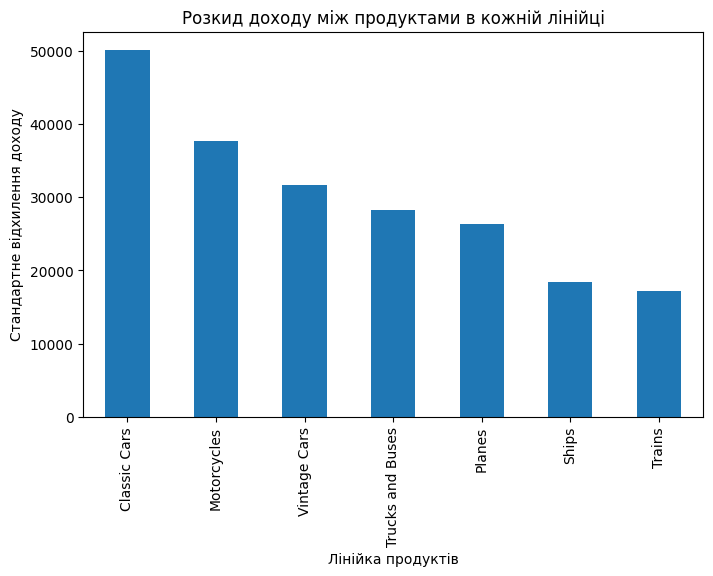

In [22]:
ax = line_variability.plot(
    x="productLine",
    y="stdRevenue",
    kind="bar",
    figsize=(8, 5),
    legend=False,
    title="Розкид доходу між продуктами в кожній лінійці"
)

ax.set_xlabel("Лінійка продуктів")
ax.set_ylabel("Стандартне відхилення доходу");

1. Найбільший внесок у загальний дохід компанії робить продукт 1992 Ferrari 360 Spider red, який формує 2.88 % від усього доходу. Це означає, що цей продукт є одним із ключових драйверів продажів.

2. Дохід ТОП1 продукту перевищує дохід 10-го продукту в топі у 2.04 рази, що свідчить про помітну концентрацію виручки серед лідерів асортименту.

3. Дві найприбутковіші лінійки продуктів разом формують 58.84 % від всіх продажів. Це свідчить про те, що значна частина доходу компанії залежить від обмеженої кількості продуктових напрямів.

4. За принципом Парето 72 продукта забезпечують 80% загального доходу. Це означає, що дохід розподілений відносно рівномірно між продуктами і значна частина асортименту робить вклад у формування основної частини виручки.

5. Додатковий аналіз показав, що найбільший розкид доходів між продуктами спостерігається в лінійці Classic Cars. Це свідчить про нерівномірний розподіл продажів у цій категорії: деякі продукти генерують значно більший дохід, ніж інші.

### ОПЦІОНАЛЬНО. Завдання 4: Аналітичний запит - Динаміка продажів по місяцях (8 балів)

**Проведіть аналіз динаміки продажів по місяцях** та для цього дістаньте з бази інформацію з наступними полями:
- Рік та місяць замовлень
- Кількість замовлень за цей рік-місяць
- Загальний дохід (quantityOrdered * priceEach) за цей рік-місяць
- На який % ми зросли за доходом порівняно з попереднім місяцем
- Накопичувальний дохід до цього місяця за рік
- Ковзне середнє доходу за 3 місяці
- Ранг цього місяця за доходом

Використайте:
- **CTE** для агрегації продажів по місяцях
- **Віконні функції** для розрахунку:
  - Зростання доходу порівняно з попереднім місяцем (LAG)
  - Накопичувальний дохід за рік
  - Ковзне середнє доходу за 3 місяці (AVG OVER)
  - Ранжування місяців за доходом (RANK)

Після отримання даних з БД побудуйте наступні графіки і напишіть коротко, які висновки з них можна зробити.
1. Створіть лінійний графік доходу по місяцях. Чи є тред до зростання в даних?
2. Створіть графік місяць-до-місяця зростання у відсотках.
3. Створіть heatmap сезонності (місяць vs рік)
4. Відобразіть козвне середнє разом з динамікою продажів.
5. Розрахуйте кореляцію між кількістю замовлень та середнім чеком та побудуйте графік розсіювання між цими змінними. Чи є лінійна залежність?

Очікуваний результат кожного графіку - нижче.
В першому графіку я додала лінію тренду аби показати тренд. Вам її додавати не треба.


In [23]:
query = text("""
WITH monthly_sales AS (
    SELECT
        YEAR(o.orderDate) AS year,
        MONTH(o.orderDate) AS month,
        COUNT(DISTINCT o.orderNumber) AS orderCount,
        SUM(od.quantityOrdered * od.priceEach) AS totalRevenue
    FROM orders o
    JOIN orderdetails od
        ON o.orderNumber = od.orderNumber
    GROUP BY
        YEAR(o.orderDate),
        MONTH(o.orderDate)
)
SELECT
    year,
    month,
    orderCount,
    totalRevenue,

    ROUND(
        (totalRevenue - LAG(totalRevenue) OVER (ORDER BY year, month))
        * 100.0
        / LAG(totalRevenue) OVER (ORDER BY year, month),
        2
    ) AS revenueGrowthPct,

    SUM(totalRevenue) OVER (
        PARTITION BY year
        ORDER BY month
        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    ) AS cumulativeRevenue,

    ROUND(
        AVG(totalRevenue) OVER (
            ORDER BY year, month
            ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
        ),
        2
    ) AS rollingAvg3Months,

    RANK() OVER (ORDER BY totalRevenue DESC) AS revenueRank

FROM monthly_sales
ORDER BY year, month
""")

df_monthly = pd.read_sql(query, engine)
df_monthly.head()

,year,month,orderCount,totalRevenue,revenueGrowthPct,cumulativeRevenue,rollingAvg3Months,revenueRank
0,2003,1,5,116692.77,NaN,116692.77,116692.77,29
1,2003,2,3,128403.64,10.04,245096.41,122548.21,28
2,2003,3,6,160517.14,25.01,405613.55,135204.52,26
3,2003,4,7,185848.59,15.78,591462.14,158256.46,23
4,2003,5,6,179435.55,-3.45,770897.69,175267.09,24


In [24]:
df_monthly.info()
df_monthly

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               29 non-null     int64  
 1   month              29 non-null     int64  
 2   orderCount         29 non-null     int64  
 3   totalRevenue       29 non-null     float64
 4   revenueGrowthPct   28 non-null     float64
 5   cumulativeRevenue  29 non-null     float64
 6   rollingAvg3Months  29 non-null     float64
 7   revenueRank        29 non-null     int64  
dtypes: float64(4), int64(4)
memory usage: 1.9 KB


,year,month,orderCount,totalRevenue,revenueGrowthPct,cumulativeRevenue,rollingAvg3Months,revenueRank
0,2003,1,5,116692.77,NaN,116692.77,116692.77,29
1,2003,2,3,128403.64,10.04,245096.41,122548.21,28
2,2003,3,6,160517.14,25.01,405613.55,135204.52,26
3,2003,4,7,185848.59,15.78,591462.14,158256.46,23
4,2003,5,6,179435.55,-3.45,770897.69,175267.09,24
5,2003,6,7,150470.77,-16.14,921368.46,171918.30,27
6,2003,7,7,201940.36,34.21,1123308.82,177282.23,21
7,2003,8,5,178257.11,-11.73,1301565.93,176889.41,25
8,2003,9,8,236697.85,32.78,1538263.78,205631.77,19
9,2003,10,18,514336.21,117.30,2052599.99,309763.72,3


In [25]:
df_monthly["avgCheck"] = df_monthly["totalRevenue"] / df_monthly["orderCount"]
df_monthly.head()

,year,month,orderCount,totalRevenue,revenueGrowthPct,cumulativeRevenue,rollingAvg3Months,revenueRank,avgCheck
0,2003,1,5,116692.77,NaN,116692.77,116692.77,29,23338.554000
1,2003,2,3,128403.64,10.04,245096.41,122548.21,28,42801.213333
2,2003,3,6,160517.14,25.01,405613.55,135204.52,26,26752.856667
3,2003,4,7,185848.59,15.78,591462.14,158256.46,23,26549.798571
4,2003,5,6,179435.55,-3.45,770897.69,175267.09,24,29905.925000


In [26]:
df_monthly["date"] = pd.to_datetime(
    df_monthly["year"].astype(str) + "-" + df_monthly["month"].astype(str) + "-01"
)

df_monthly.head()

,year,month,orderCount,totalRevenue,revenueGrowthPct,cumulativeRevenue,rollingAvg3Months,revenueRank,avgCheck,date
0,2003,1,5,116692.77,NaN,116692.77,116692.77,29,23338.554000,2003-01-01
1,2003,2,3,128403.64,10.04,245096.41,122548.21,28,42801.213333,2003-02-01
2,2003,3,6,160517.14,25.01,405613.55,135204.52,26,26752.856667,2003-03-01
3,2003,4,7,185848.59,15.78,591462.14,158256.46,23,26549.798571,2003-04-01
4,2003,5,6,179435.55,-3.45,770897.69,175267.09,24,29905.925000,2003-05-01


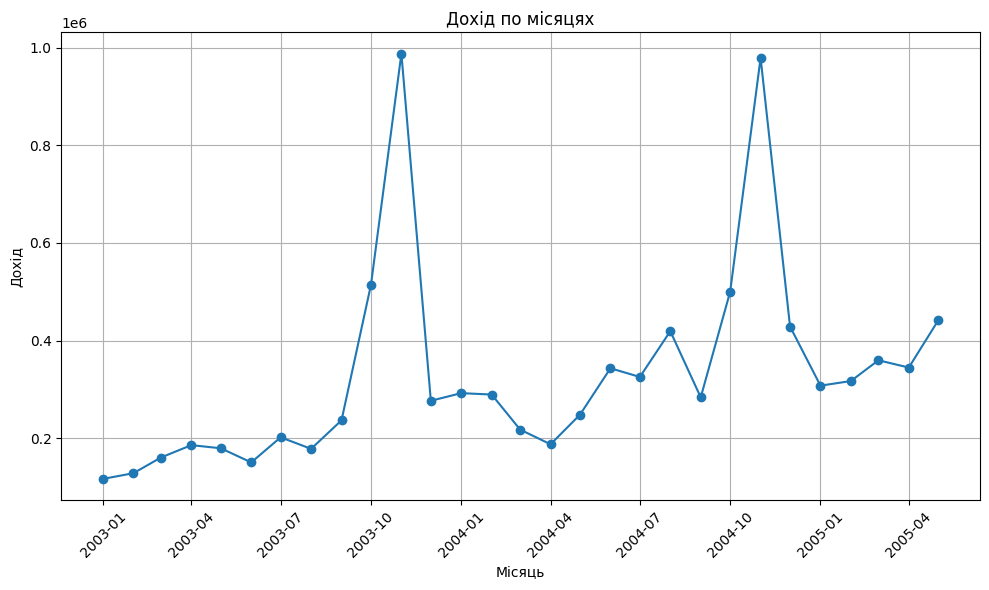

In [27]:
# 1. Лінійний графік доходу з трендом (аби показати, що тренд є)

plt.figure(figsize=(10, 6))
plt.plot(df_monthly["date"], df_monthly["totalRevenue"], marker="o")
plt.title("Дохід по місяцях")
plt.xlabel("Місяць")
plt.ylabel("Дохід")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Дохід по місяцях змінюється нерівномірно: в окремі періоди спостерігаються піки та спади. Але загальна лінія має висхідний напрямок, тому можна говорити про помірний тренд до зростання.

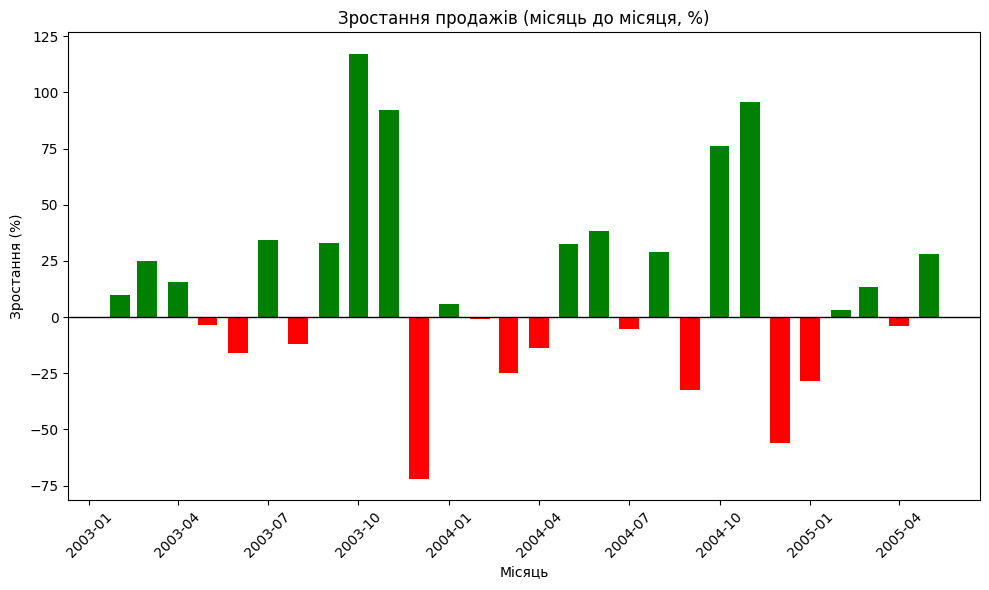

In [28]:
# 2. Місяць-до-місяця зростання

colors = df_monthly["revenueGrowthPct"].apply(lambda x: "green" if x >= 0 else "red")
plt.figure(figsize=(10,6))
plt.bar(
    df_monthly["date"],
    df_monthly["revenueGrowthPct"],
    color=colors,
    width=20
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Зростання продажів (місяць до місяця, %)")
plt.xlabel("Місяць")
plt.ylabel("Зростання (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Графік місяць-до-місяця показує, що темпи зростання продажів є нестабільними: у різні періоди спостерігаються як значні підйоми, так і помітні спади. У деякі місяці фіксується різке зростання продажів, що може бути пов'язано з сезонністю або великими замовленнями клієнтів. Водночас є місяці зі значним падінням доходу, що свідчить про нерівномірність попиту протягом року. Загалом графік показує, що продажі компанії мають циклічний характер і можуть значно змінюватися від місяця до місяця.

In [29]:
pivot_sales = df_monthly.pivot(
    index="month",
    columns="year",
    values="totalRevenue"
)

pivot_sales

year,2003,2004,2005
month,,,
1,116692.77,292385.21,307737.02
2,128403.64,289502.84,317192.17
3,160517.14,217691.26,359711.96
4,185848.59,187575.77,344820.62
5,179435.55,248325.30,441474.94
6,150470.77,343370.74,NaN
7,201940.36,325563.49,NaN
8,178257.11,419327.09,NaN
9,236697.85,283799.80,NaN


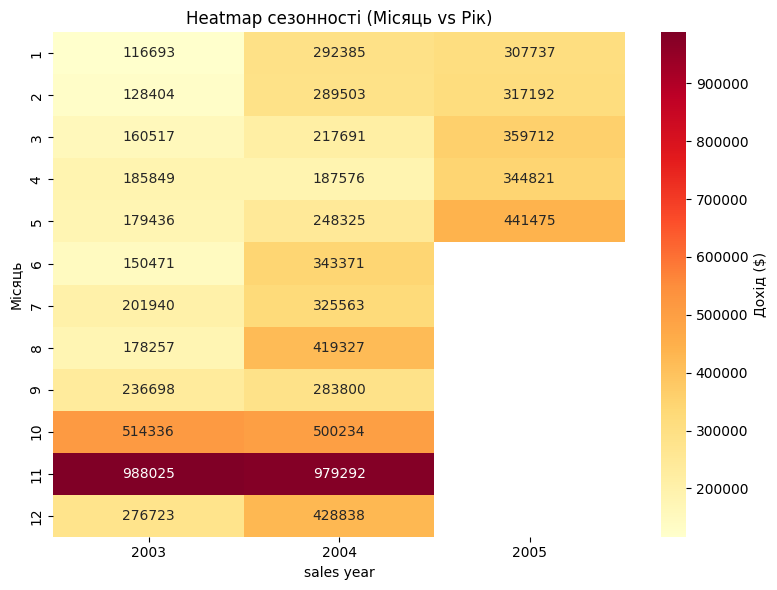

In [30]:
# 3. Heatmap сезонності
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot_sales,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    cbar_kws={'label': 'Дохід ($)'}
)

plt.title("Heatmap сезонності (Місяць vs Рік)")
plt.xlabel("sales year")
plt.ylabel("Місяць")

plt.tight_layout()
plt.show()

Heatmap показує, що доходи мають сезонні коливання. Найвищий дохід спостерігається у листопаді, що може бути пов'язано з підвищеним попитом наприкінці року. Натомість у перші місяці року доходи зазвичай нижчі, що свідчить про можливу сезонність продажів.

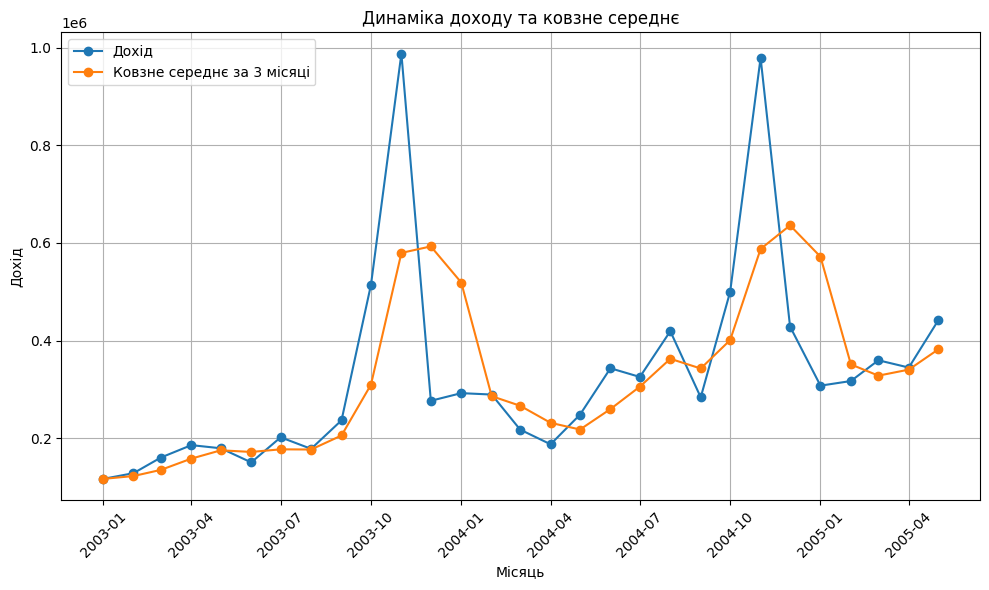

In [31]:
# 4. Ковзне середнє з динімікою доходу
plt.figure(figsize=(10, 6))
plt.plot(df_monthly["date"], df_monthly["totalRevenue"], marker="o", label="Дохід")
plt.plot(df_monthly["date"], df_monthly["rollingAvg3Months"], marker="o", label="Ковзне середнє за 3 місяці")
plt.title("Динаміка доходу та ковзне середнє")
plt.xlabel("Місяць")
plt.ylabel("Дохід")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Графік показує, що дохід по місяцях змінюється нерівномірно та має різкі піки в окремі періоди. Найбільші значення доходу спостерігаються у листопаді, що може свідчити про сезонне зростання попиту. Ковзне середнє за 3 місяці згладжує різкі коливання та дозволяє краще побачити тенденцію продажів. Загалом динаміка продажів показує періодичні підйоми та спади, але в окремі періоди простежується тенденція до зростання доходу.

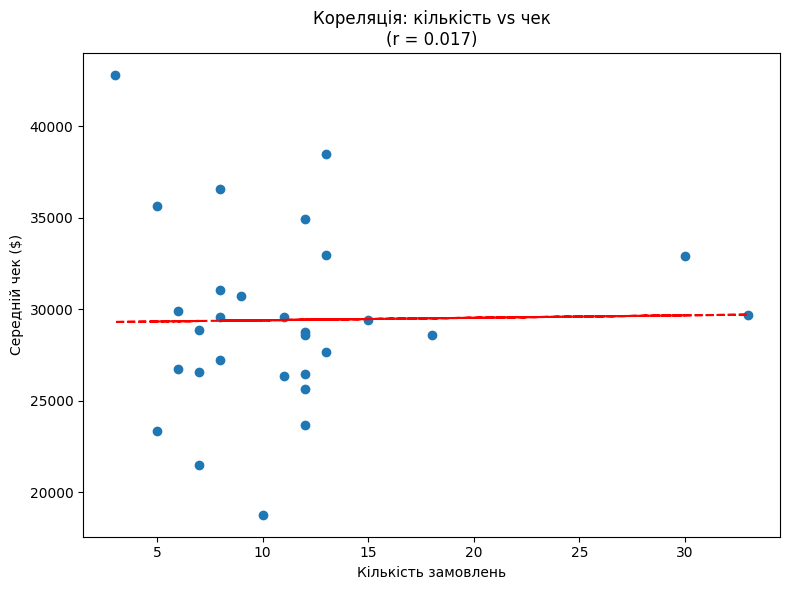

In [32]:
# 5. Кореляція замовлень та середнього чеку
import numpy as np

corr = df_monthly["orderCount"].corr(df_monthly["avgCheck"])

plt.figure(figsize=(8,6))
plt.scatter(df_monthly["orderCount"], df_monthly["avgCheck"])
z = np.polyfit(df_monthly["orderCount"], df_monthly["avgCheck"], 1)
p = np.poly1d(z)
plt.plot(
    df_monthly["orderCount"],
    p(df_monthly["orderCount"]),
    "r--"
)

plt.title(f"Кореляція: кількість vs чек\n(r = {corr:.3f})")
plt.xlabel("Кількість замовлень")
plt.ylabel("Середній чек ($)")
plt.tight_layout()
plt.show()

Є аутлаєри, але в загальному не можна сказати, що кореляція присутня.

Графік розсіювання показує зв'язок між кількістю замовлень та середнім чеком. Кефіцієнт кореляції становить 0.033, що свідчить про практично відсутній лінійний зв'язок між цими показниками. Тобто, збільшення кількості замовлень не супроводжується системним зростанням або зменшенням середнього чеку. Точки на графіку розташовані хаотично, що також підтверджує відсутність чіткої лінійної залежності між змінними.